
**<DNN 기반 Binary classification>**
- 해당 내용은 실무 개발에서 많이 사용되는 DNN 구조로 암기하면 된다.

In [ ]:
import torch
import pandas as pd

# CSV 파일 불러오기
df = pd.read_csv('/home/hjj747/deepLearning/nn/classify5k.csv')

# data와 labels 추출
data = df[['x', 'y']].values
labels = df['label'].values.reshape(-1,1)

# data와 labels 형태 확인
print(f"Data shape: {data.shape}")
print(f"Labels shape: {labels.shape}")



Data shape: (5000, 2)
Labels shape: (5000, 1)


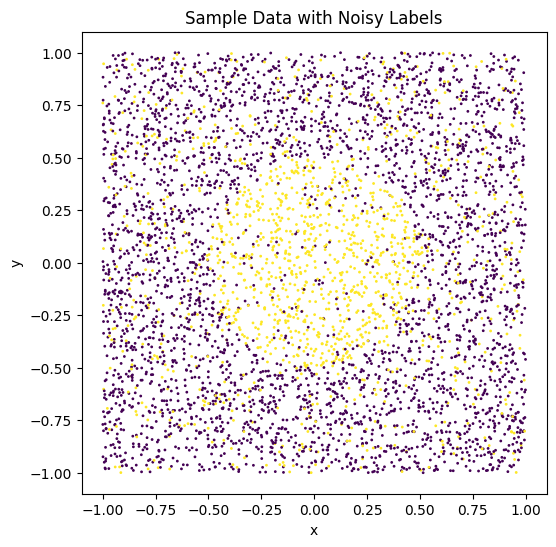

In [4]:
import matplotlib.pyplot as plt

# 불러온 데이터 시각화
plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', s=1)
plt.title('Sample Data with Noisy Labels')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
# 데이터를 PyTorch 텐서로 변환하고, 학습과 검증 데이터로 분할
data_torch = torch.tensor(data, dtype=torch.float32)
labels_torch = torch.tensor(labels, dtype=torch.float32)
data_length = len(data_torch)
split_length = int(0.8 * data_length)

# 학습 데이터와 검증 데이터로 분할
train_data = data_torch[:split_length]
train_labels = labels_torch[:split_length]
val_data = data_torch[split_length:]
val_labels = labels_torch[split_length:]

print(f"Train data shape: {train_data.shape}")
print(f"Train labels shape: {train_labels.shape}")

Train data shape: torch.Size([4000, 2])
Train labels shape: torch.Size([4000, 1])


In [ ]:
# 무작위 시드 설정
g = torch.Generator().manual_seed(42)

# 배치 크기만큼 무작위로 데이터를 선택하는 함수
def get_batch(data, labels, batch_size=256):

    indices = torch.randint(0, len(data), (batch_size,), generator=g)
    
    data_batch = data[indices]
    labels_batch = labels[indices]

    return data_batch, labels_batch

data_batch, labels_batch = get_batch(train_data, train_labels)
print(f"Data batch shape: {data_batch.shape}")
print(f"Labels batch shape: {labels_batch.shape}")

Data batch shape: torch.Size([256, 2])
Labels batch shape: torch.Size([256, 1])


In [18]:
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim

# 무작위로 선택된 배치에 대해 간단한 DNN 연산 수행
data_batch, labels_batch = get_batch(train_data, train_labels)

# DNN의 입력, 은닉층, 출력층 크기 설정
input_size = 2
hidden_size = 4
output_size = 1

# 무작위 시드 설정
g.manual_seed(42)

# DNN 모델 정의
class Net(nn.Module):

    # DNN의 초기화 함수 정의 (선형 계층과 활성화 함수 설정)
    def __init__(self):
        super().__init__()

        # DNN의 계층을 순차적으로 정의 (선형 계층과 ReLU 활성화 함수 사용)
        self.seq_model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    # DNN의 forward 함수 정의 (ReLU 활성화 함수 사용)
    def forward(self, x : torch.Tensor):
        return self.seq_model(x)

# DNN 모델 인스턴스 생성
net = Net()

# BCEWithLogitsLoss 함수 정의 (이 함수는 내부적으로 시그모이드 함수를 적용하므로, output을 그대로 사용)
lossfn = nn.BCEWithLogitsLoss()

# SGD 옵티마이저 정의 (모델의 모든 매개변수를 업데이트하도록 설정)
optimizer = optim.SGD(net.parameters(), lr=0.01)



# 간단한 DNN 연산과 손실 계산
for steps in range(200000):
    # 무작위로 선택된 배치에 대해 DNN 연산 수행
    data_batch, labels_batch = get_batch(train_data, train_labels)
    output = net(data_batch)
    
    # BCEWithLogitsLoss를 사용하여 손실 계산 (이 함수는 내부적으로 시그모이드 함수를 적용하므로, output을 그대로 사용)
    loss = lossfn(output, labels_batch)

    optimizer.zero_grad()   # 옵티마이저의 기울기 초기화 (다음 스텝을 위해)
    loss.backward()         # 역전파 수행
    optimizer.step()        # 옵티마이저 스텝 수행 (모델의 매개변수 업데이트)
    

    # 1000 스텝마다 학습 손실과 검증 손실 계산 및 출력
    if steps % 1000 == 0:
        net.eval()          # DNN을 평가 모드로 설정 (예: 드롭아웃과 배치 정규화가 있는 경우, 이 모드에서는 이를 비활성화)
        output = net(val_data)
        val_loss = lossfn(output, val_labels)
        print(f"Step: {steps}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")
        net.train()         # DNN을 학습 모드로 다시 설정 (예: 드롭아웃과 배치 정규화가 있는 경우, 이 모드에서는 이를 활성화)


# 출력 형태 확인
print(f"Output shape: {output.shape}")

Step: 0, Train Loss: 0.6808, Val Loss: 0.6766
Step: 1000, Train Loss: 0.5639, Val Loss: 0.5943
Step: 2000, Train Loss: 0.5585, Val Loss: 0.5860
Step: 3000, Train Loss: 0.5769, Val Loss: 0.5783
Step: 4000, Train Loss: 0.5580, Val Loss: 0.5700
Step: 5000, Train Loss: 0.5525, Val Loss: 0.5607
Step: 6000, Train Loss: 0.5124, Val Loss: 0.5506
Step: 7000, Train Loss: 0.5326, Val Loss: 0.5406
Step: 8000, Train Loss: 0.5564, Val Loss: 0.5310
Step: 9000, Train Loss: 0.5130, Val Loss: 0.5222
Step: 10000, Train Loss: 0.4948, Val Loss: 0.5146
Step: 11000, Train Loss: 0.5013, Val Loss: 0.5082
Step: 12000, Train Loss: 0.4548, Val Loss: 0.5031
Step: 13000, Train Loss: 0.5287, Val Loss: 0.4990
Step: 14000, Train Loss: 0.4949, Val Loss: 0.4957
Step: 15000, Train Loss: 0.5056, Val Loss: 0.4929
Step: 16000, Train Loss: 0.4839, Val Loss: 0.4909
Step: 17000, Train Loss: 0.4952, Val Loss: 0.4893
Step: 18000, Train Loss: 0.5318, Val Loss: 0.4881
Step: 19000, Train Loss: 0.5040, Val Loss: 0.4871
Step: 20000, 

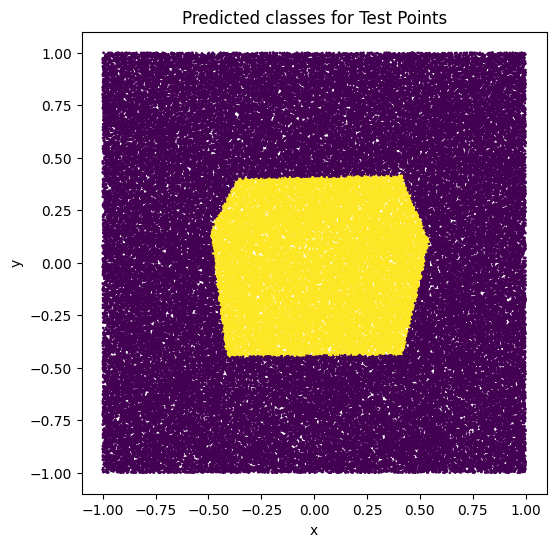

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# 테스트용 무작위 점 생성
n_points_test = 100000
points_test = np.random.uniform(-1, 1, (n_points_test, 2))
points_test_torch = torch.from_numpy(points_test).float()

net.eval()                                  # DNN을 평가 모드로 설정
output_test = net(points_test_torch)        # DNN을 사용하여 테스트 점에 대한 출력을 계산

prob = torch.sigmoid(output_test)           # 시그모이드 함수를 적용하여 확률로 변환
pred = (0.5 < prob).numpy()                 # 0.5를 기준으로 클래스 예측 (0 또는 1)

# 예측된 클래스 시각화
plt.figure(figsize=(6, 6))
plt.scatter(points_test[:, 0], points_test[:, 1], c=pred, cmap='viridis', s=1)
plt.title('Predicted classes for Test Points')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
